In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sbi.inference import NPE_C
from sbi.analysis import plot_summary

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\arviz\__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [4]:
x_o = np.loadtxt('../data/x_o.csv', delimiter=",")
x_o = x_o[:8]
x_o

array([0.16571728, 0.16576999, 0.16727886, 0.03737374, 0.03794872,
       0.03769634, 0.04516129, 0.        ])

In [5]:
x_o_2000 = np.append(x_o, 2000.0)
x_o_2000 = torch.tensor(x_o_2000, device=torch_device)
x_o_2000 = x_o_2000.to(torch.float32)
x_o_2000 = x_o_2000.flatten()
x_o_2000_numpy = x_o_2000.cpu().numpy()
x_o_2000

tensor([1.6572e-01, 1.6577e-01, 1.6728e-01, 3.7374e-02, 3.7949e-02, 3.7696e-02,
        4.5161e-02, 0.0000e+00, 2.0000e+03])

In [6]:
x_o_500 = np.append(x_o, 500.0)
x_o_500 = torch.tensor(x_o_500, device=torch_device)
x_o_500 = x_o_500.to(torch.float32)
x_o_500 = x_o_500.flatten()
x_o_500_numpy = x_o_500.cpu().numpy()
x_o_500

tensor([1.6572e-01, 1.6577e-01, 1.6728e-01, 3.7374e-02, 3.7949e-02, 3.7696e-02,
        4.5161e-02, 0.0000e+00, 5.0000e+02])

In [8]:
x_o_6000 = np.append(x_o, 6000.0)
x_o_6000 = torch.tensor(x_o_6000, device=torch_device)
x_o_6000 = x_o_6000.to(torch.float32)
x_o_6000 = x_o_6000.flatten()
x_o_6000_numpy = x_o_6000.cpu().numpy()
x_o_6000

tensor([1.6572e-01, 1.6577e-01, 1.6728e-01, 3.7374e-02, 3.7949e-02, 3.7696e-02,
        4.5161e-02, 0.0000e+00, 6.0000e+03])

In [9]:
theta = np.loadtxt('../data/theta.csv', delimiter=",")
x = np.loadtxt('../data/x.csv', delimiter=",")

In [10]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()
theta

tensor([[1.4161e-01, 1.1105e+01, 1.1919e-01, 8.4130e+03],
        [2.2739e-02, 3.6441e+02, 1.7702e-01, 7.4800e+03],
        [1.0255e-01, 1.2389e+02, 5.6109e-02, 8.4950e+03],
        ...,
        [1.8095e-04, 3.6994e+02, 8.0962e-02, 2.3370e+03],
        [1.3660e-01, 2.3934e+02, 1.5594e-01, 4.1120e+03],
        [1.2989e-01, 2.6018e+02, 1.6421e-01, 2.1640e+03]])

In [11]:
x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()
x

tensor([[7.5429e-02, 7.5469e-02, 7.5261e-02,  ..., 8.7617e-02, 0.0000e+00,
         8.4130e+03],
        [1.6166e-01, 1.6192e-01, 1.6199e-01,  ..., 1.4652e-01, 0.0000e+00,
         7.4800e+03],
        [8.8128e-02, 8.8209e-02, 8.8361e-02,  ..., 6.3736e-02, 0.0000e+00,
         8.4950e+03],
        ...,
        [2.6042e-01, 2.6056e-01, 2.6193e-01,  ..., 5.3130e-02, 0.0000e+00,
         2.3370e+03],
        [1.0982e-01, 1.1003e-01, 1.0923e-01,  ..., 2.4196e-01, 0.0000e+00,
         4.1120e+03],
        [1.0469e-01, 1.0457e-01, 1.0532e-01,  ..., 2.3667e-01, 0.0000e+00,
         2.1640e+03]])

In [12]:
theta.shape, x.shape

(torch.Size([5000, 4]), torch.Size([5000, 9]))

In [13]:
x_o_2000.dtype, x_o_500.dtype, x_o_6000.dtype, theta.dtype, x.dtype

(torch.float32, torch.float32, torch.float32, torch.float32, torch.float32)

In [14]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference = NPE_C(density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [15]:
density_estimator = inference.append_simulations(theta, x).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 244 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-04-23T10_22_06.173766' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


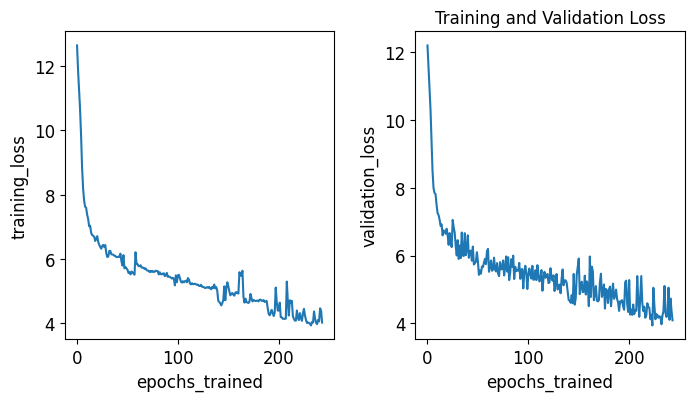

In [16]:
fig, axes = plot_summary(
    inference, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

In [18]:
theta_trained_2000 = posterior.set_default_x(x_o_2000).sample((num_posterior_samples,), x=x_o_2000)
theta_trained_2000_numpy = theta_trained_2000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 35790.02it/s]


In [19]:
theta_trained_500 = posterior.set_default_x(x_o_500).sample((num_posterior_samples,), x=x_o_500)
theta_trained_500_numpy = theta_trained_500.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 23703.60it/s]


In [20]:
theta_trained_6000 = posterior.set_default_x(x_o_6000).sample((num_posterior_samples,), x=x_o_6000)
theta_trained_6000_numpy = theta_trained_6000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 43118.45it/s]


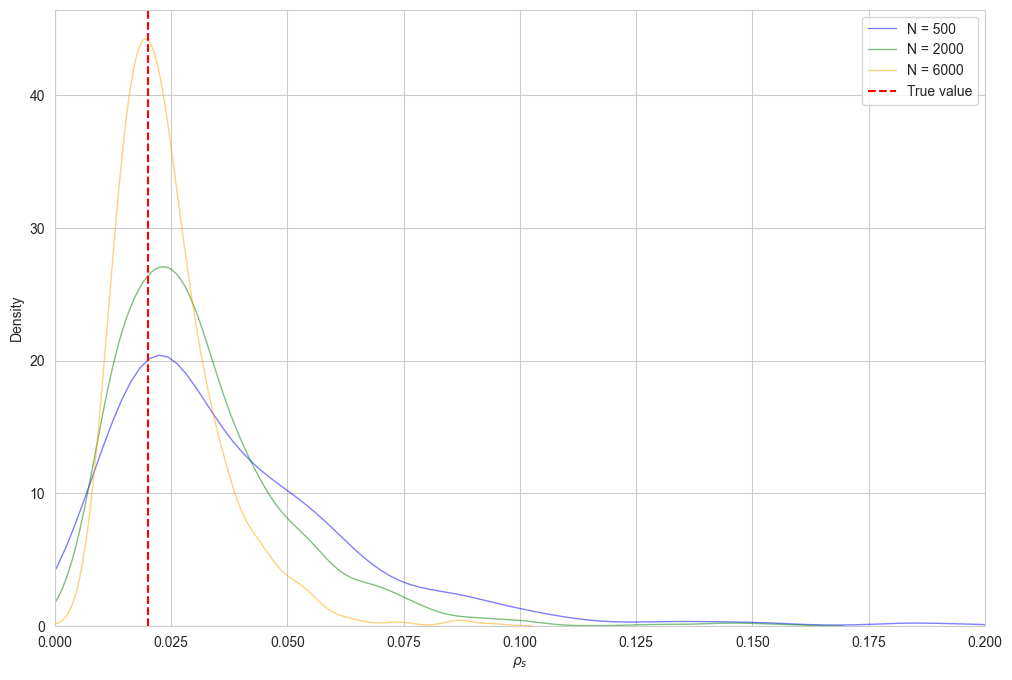

In [21]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 0], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 0], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 0], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.2)
plt.legend()
plt.show()

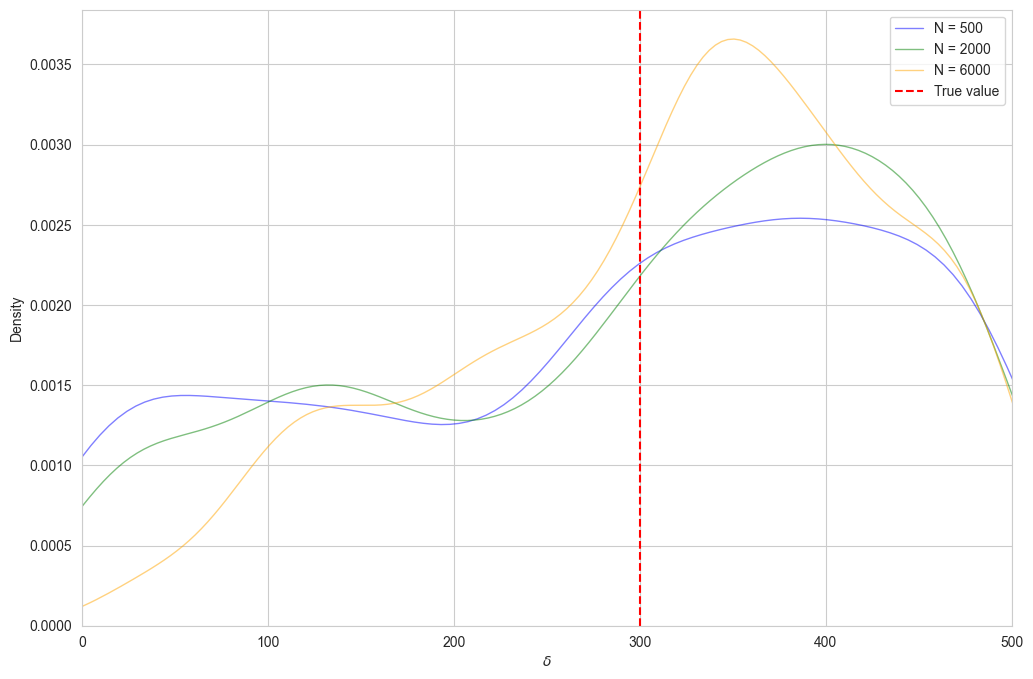

In [27]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 1], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 1], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 1], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=300, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\delta$')
plt.xlim(0.0, 500.0)
plt.legend()
plt.show()

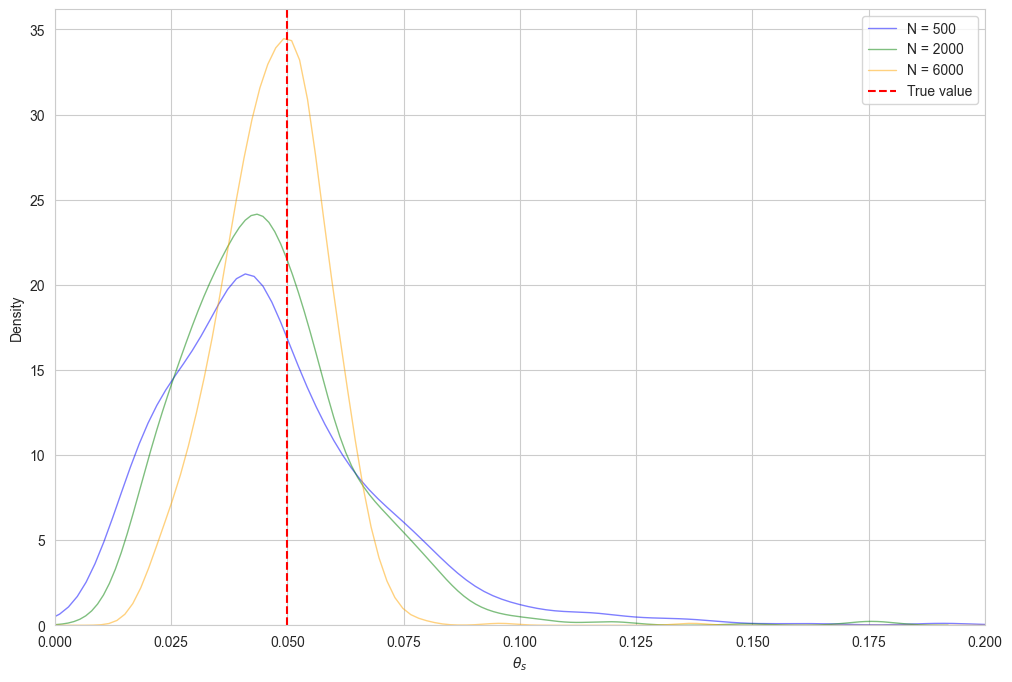

In [24]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 2], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 2], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 2], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.05, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\theta_s$')
plt.xlim(0.0, 0.2)
plt.legend()
plt.show()

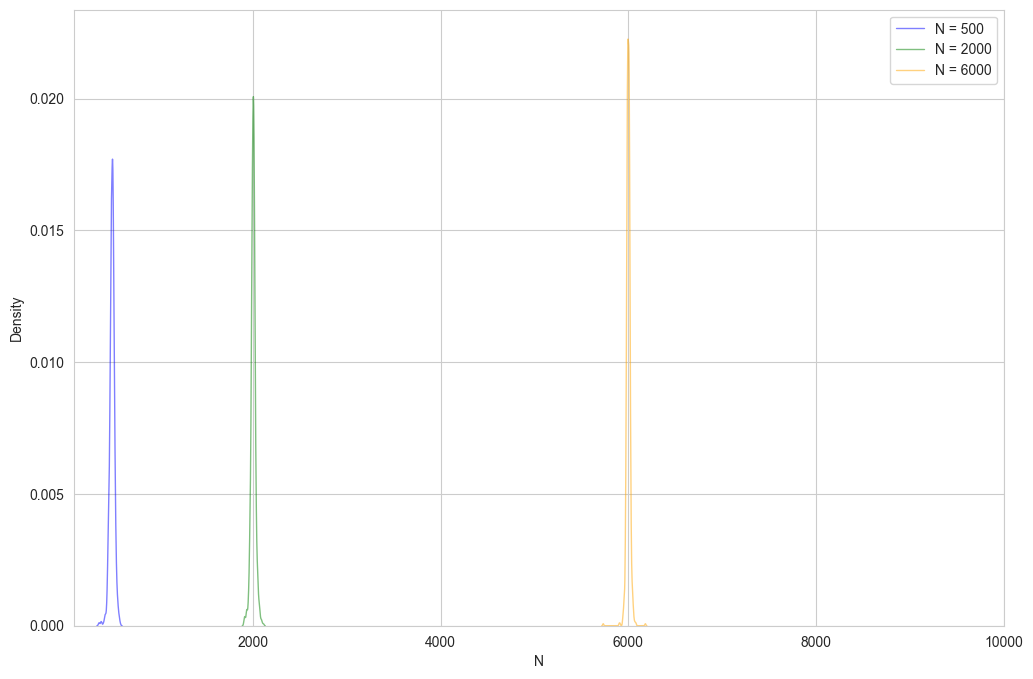

In [25]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 3], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 3], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 3], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

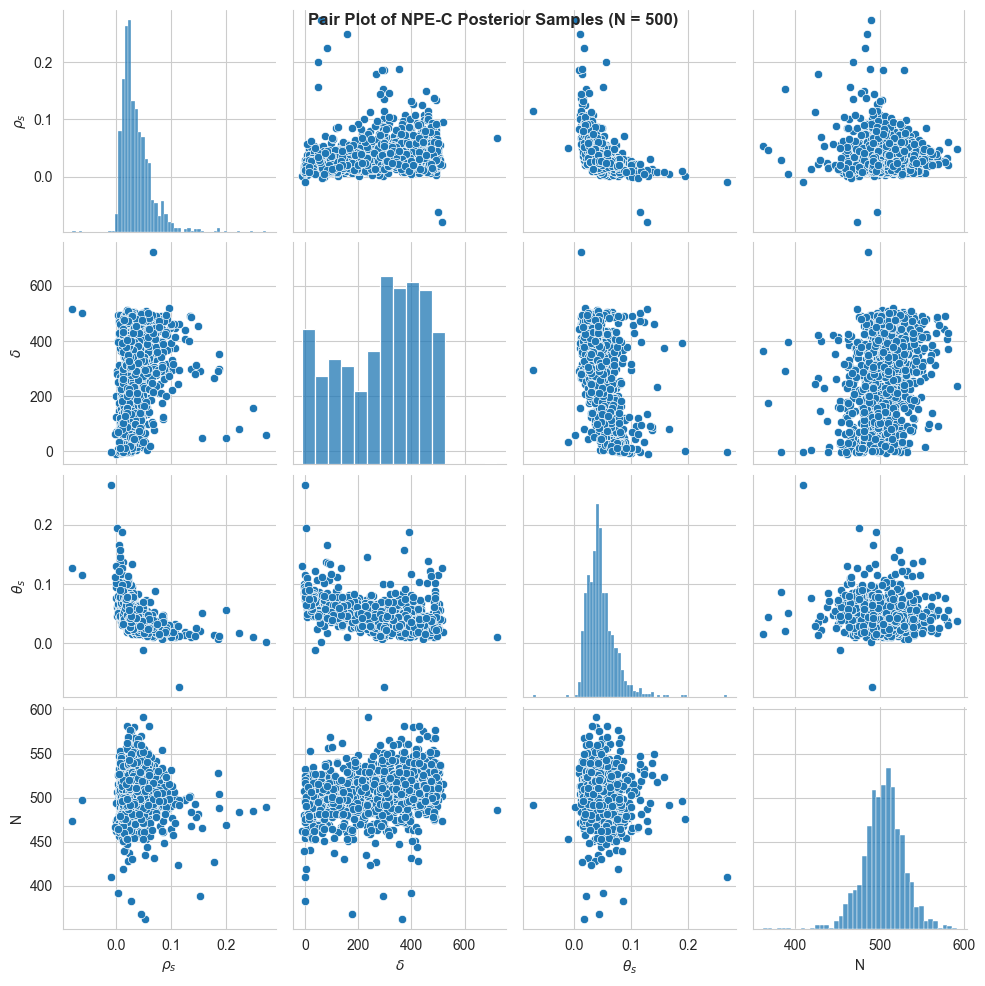

In [28]:
df_500 = pd.DataFrame(theta_trained_500_numpy, columns=[r"$\rho_s$", r"$\delta$", r"$\theta_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

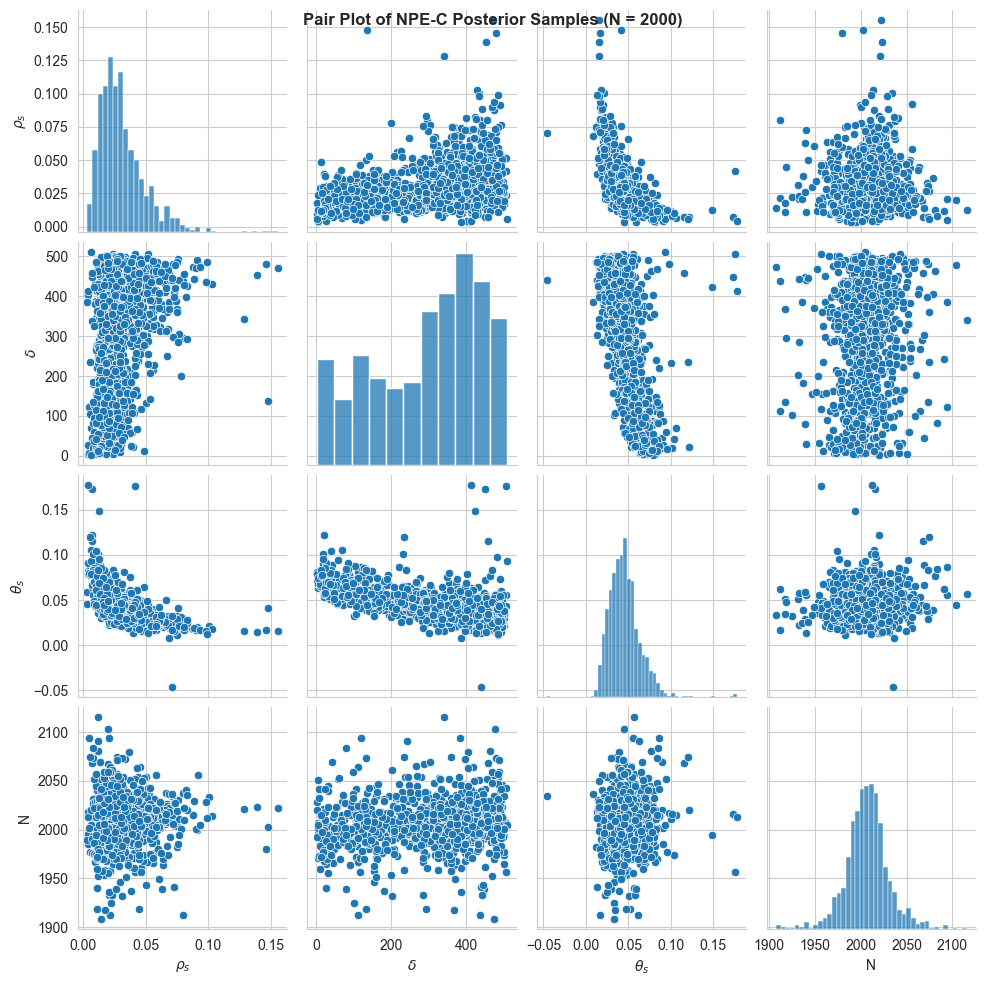

In [29]:
df_2000 = pd.DataFrame(theta_trained_2000_numpy, columns=[r"$\rho_s$", r"$\delta$", r"$\theta_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

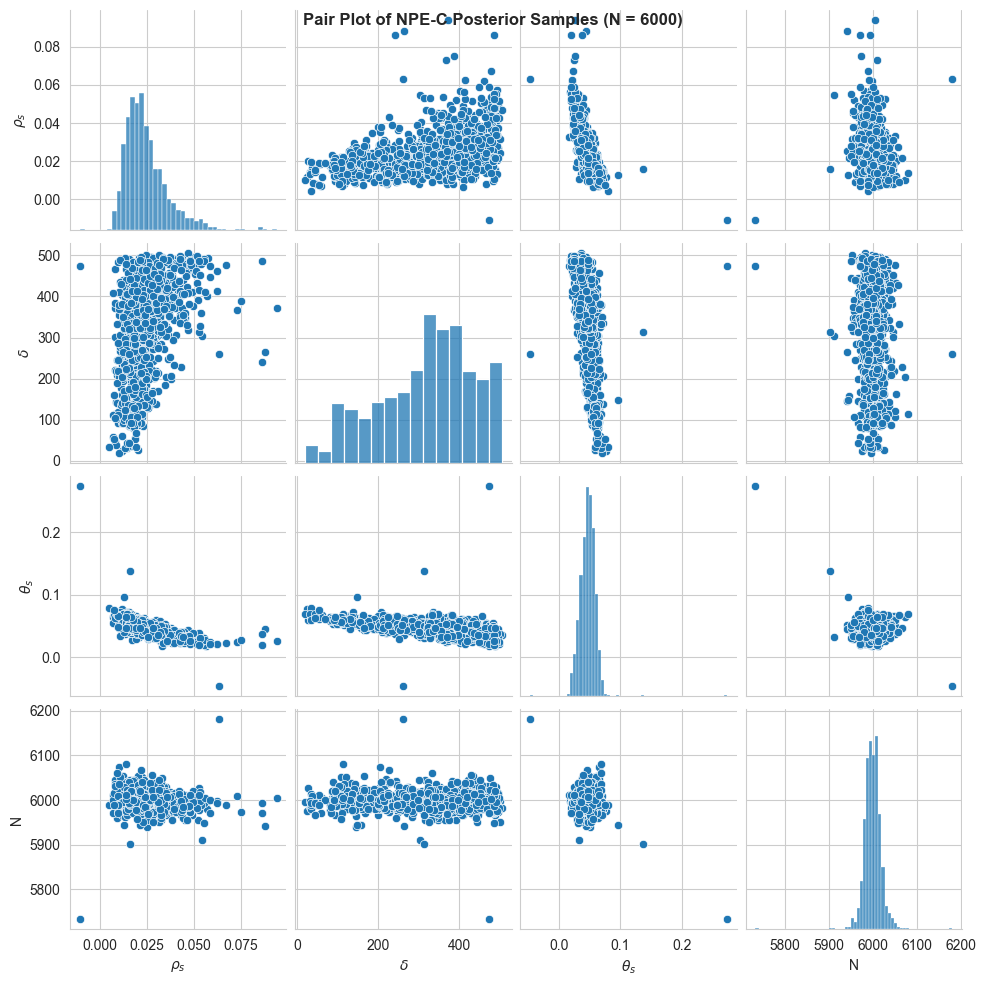

In [30]:
df_6000 = pd.DataFrame(theta_trained_6000_numpy, columns=[r"$\rho_s$", r"$\delta$", r"$\theta_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()